# **Multiple Linear Regression with SciKit-Learn**


**Key Question:**

*How does each advertising channel (TV, Radio, Newspaper) individually affect sales?*



Previously: simple linear regression → one feature (total spend)

Now: multiple linear regression → several features

Why this matters:
- Identifies which channels matter
- *Guides* budget allocation decisions

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Load & Inspect the Dataset**

In [5]:
df = pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


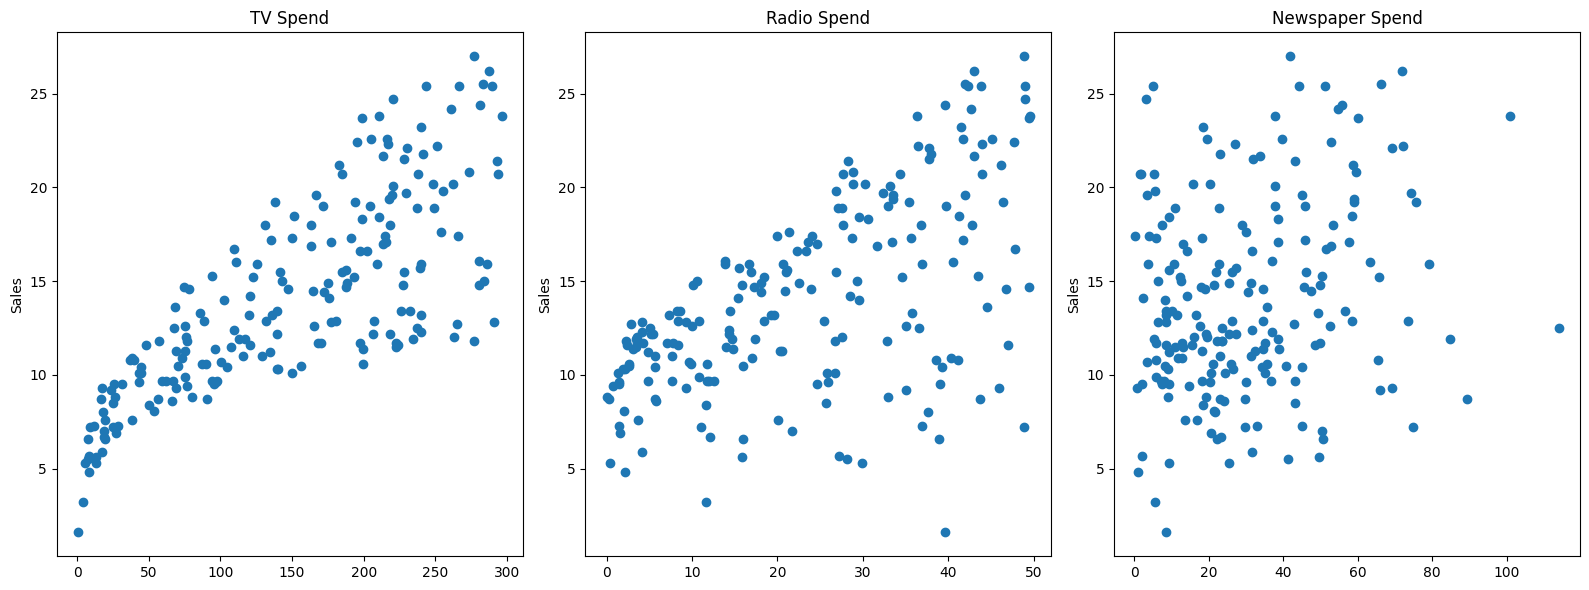

In [6]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_title("Newspaper Spend");
axes[2].set_ylabel("Sales")
plt.tight_layout();

- Which features show a clear trend?

- Which look noisy or weak?

# **Feature / Label Separation**

X = features (independent variables)

y = label (dependent variable)

In [7]:
X = df.drop("sales", axis=1)
y = df["sales"]

# **Train, Test, and Validation Data**

In machine learning, we are not trying to memorize data.
We are trying to learn a pattern that works on new, unseen data.

**How do we know if a model will work on data it has never seen before?** Splitting data



A train–test split means dividing our dataset into two separate parts:

- **Training set**
  - Used to learn model parameters
  - The model sees this data during learning

- **Test set**
  - Used only after training
  - Measures how well the model generalizes

📌 **Key rule:**

The test set must behave like “future data.”

If the model sees test data during training, the evaluation is meaningless.

### **Why This Matters?**

- **A clean split ensures the model is evaluated only on data it has never seen before.**

  - **Data leakage:** Happens when information from the test set influences the training process.

  - If a model “sees” test data during training, its performance looks better than it truly is — but it will fail on real, unseen data.

- **Provide an honest estimate of generalization.**

  - Ensures fair evaluation
  - The test set acts like a final exam.
  - Training accuracy ≠ real-world performance.



### **Train–Test vs Train–Validation–Test**

- **Two-way split (Train / Test)**

  - Used when:
    - Dataset is small
    - Model is simple
    - Minimal tuning is required

  - Workflow:
    - Train model
    - Evaluate once

- **Three-way split (Train / Validation / Test)**

  - Used when:
    - Hyperparameters must be tuned
    - Multiple models are compared
    - Fair final evaluation is required

  - Roles:
    - Training set → learn parameters
    - Validation set → tune hyperparameters
    - Test set → final, untouched evaluation

📌 **Golden rule:** The test set is used exactly once at the end.

If tune using the test set: That is also **data leakage**

### **Shuffling**

- sk-learn train_test_split **shuffles the data by default**
- Prevents **ordered data bias**

  Example of bias:
    - Dataset ordered by time
    - Dataset grouped by class
    - Increasing trend in feature values

  Without shuffling:
  - Training and test sets may come from different distributions
  - Evaluation becomes biased
  - Model may train on only “easy” examples
  - Test set may contain only “hard” or “late” examples

📌 **Shuffling ensures: Train and test represent the same population.**

### **When Should We NOT Shuffle?**

  There are important exceptions:

 **Time-series data**

  - Stock prices
  - Sensor measurements
  - Clinical timelines

  Here:

  - Order carries information
  - Shuffling breaks causality

  📌 In these cases: **Train on the past → test on the future**

### **Reproducibility and Randomness**

Splitting involves randomness.

Without control:

- Every run produces different results

By fixing a seed:

- Experiments become reproducible
- Results are comparable
- Debugging is possible



##**Train_Test Split using Numpy**

How It Works:

- Shuffle indices to randomize data order.
- Split a portion for the test set based on test_size.
- Use NumPy indexing to pick samples for training and testing

In [8]:
import numpy as np

# -------------------------------
# Function to perform train-test split
# -------------------------------
def train_test_split_numpy(X, y, test_size=0.3, random_state=None):
    """
    Splits arrays or matrices into random train and test subsets using NumPy only.
    """
    if random_state is not None:
        np.random.seed(random_state)

    # Determine number of test samples
    n_samples = X.shape[0]
    n_test = int(n_samples * test_size)

    # Generate shuffled indices
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    # Split indices for train and test
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    # Return the corresponding subsets (use iloc for pandas)
    X_train = X.iloc[train_indices]
    X_test  = X.iloc[test_indices]
    y_train = y.iloc[train_indices]
    y_test  = y.iloc[test_indices]

    # Return the corresponding subsets (in case of pure numpy)
    #X_train, X_test = X[train_indices], X[test_indices]
    #y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

# -------------------------------
# Example usage
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split_numpy(X, y, test_size=0.3, random_state=42)
print("\n\n")
print("X_train:\n", X_train.shape)
print("y_train:", y_train.shape)
print("\nX_test:\n", X_test.shape)
print("y_test:", y_test.shape)





X_train:
 (140, 3)
y_train: (140,)

X_test:
 (60, 3)
y_test: (60,)


## **Train_Test Split using sklearn**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## **Model Creation & Training**

- Estimator = untrained model
- .fit() performs learning (gradient descent internally)
- In essence, for the LinearRegression model in scikit-learn, `fit()` is indeed solving the least squares problem, and it will often use an optimized OLS solver. However, the general idea that `fit()` involves an iterative learning process (like gradient descent) to minimize a loss function is applicable to a vast array of models, making it a useful conceptual generalization.

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## **Predictions on Test Data**

Never evaluate on training data

In [11]:
test_predictions = model.predict(X_test)

<br><br>

## **Regression Metrics**

Regression metrics quantify **how far predictions are from true values**.  
Each metric emphasizes error **differently**, so choosing the right one depends on the problem.



<br>

### **Mean Absolute Error (MAE)**

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

#### **What It Measures**
- Average **absolute distance** between predictions and true values
- Treats all errors **equally**

✅ **Pros**
- Easy to interpret
- Same units as the target variable
- Robust to outliers

❌ **Cons**
- Does not heavily penalize large errors
- Not differentiable at zero (minor issue in practice)

#### **When to Use**
- When **every error matters equally**
- When outliers should not dominate the metric

#### **Example**
House price prediction:
- Being off by 5k or 10k matters proportionally
- No single bad prediction should dominate evaluation



<br>

### **Mean Squared Error (MSE)**

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### **What It Measures**
- Average **squared error**
- Penalizes large errors **quadratically**

✅ **Pros**
- Strongly penalizes large mistakes
- Smooth and differentiable (great for optimization)
- Common loss function in training

❌ **Cons**
- Sensitive to outliers
- Units are **squared**, not interpretable directly

#### **When to Use**
- When **large errors are especially bad**
- During model training and optimization

#### **Example**
Medical dosage prediction:
- A large error can be dangerous
- You want to heavily penalize big mistakes



<br>

### **Root Mean Squared Error (RMSE)**

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

#### **What It Measures**
- Square root of MSE
- Error magnitude in **original units**

✅ **Pros**
- Interpretable (same units as target)
- Penalizes large errors
- Most commonly reported metric

❌ **Cons**
- Still sensitive to outliers
- Harder to optimize directly

#### **When to Use**
- When you want **interpretability + large-error penalty**
- For reporting final model performance

#### **Example**
Weather temperature prediction:
- Errors in degrees make sense
- Large errors should stand out


In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

MAE = mean_absolute_error(y_test,test_predictions)
print(MAE)
MSE = mean_squared_error(y_test,test_predictions)
print(MSE)
RMSE = np.sqrt(MSE)
print(RMSE)

1.213745773614481
2.2987166978863796
1.5161519375993884


### **Interpretation:**

  - **Comparing MAE to the Mean:**

    *“How large is the typical error relative to a typical value?”*

  - **Comparing RMSE to the Mean:**

    *“How bad can errors get relative to typical scale?”*

In [13]:
print( (RMSE / df['sales'].mean() )* 100 )

10.81227981885818


### **Is this error acceptable?**

  We are really asking:
  -Will this error change decisions?
  -Does it affect revenue?
  - Does it cause risk?

Examples:

- ❌ Medical dosing → 10% may be unacceptable
- ✅ Sales forecasting → 10% may be perfectly fine
- ❌ Inventory planning → depends on margins

**Accuracy is context-dependent, not absolute.**

<br><br>

## **Performane Metrics**

### **R-squared ($R^2$) - Coefficient of Determination**

R-squared ($R^2$) is fundamentally different from MAE, MSE, and RMSE! While MAE, MSE, and RMSE focus on the magnitude of the prediction errors (how far off your predictions are from the actual values), R-squared measures the explanatory power of your model.


$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{\text{MSE}}{\text{Variance}(y)}$$



#### **What makes it different?**

Unlike MAE, MSE, and RMSE which quantify the average error in your predictions (and are in units related to your target variable), R-squared tells you how much of the variation in your dependent variable (the thing you're trying to predict) can be explained by your independent variables (your features). It's a measure of fit, indicating how well your model's predictions align with the actual data's fluctuations.



- **Explanatory Power:** While MAE/MSE/RMSE tell you how much error your model has, $R^2$ tells you how much of the phenomenon your model is capturing. For example, if your $R^2 = 0.75$$R^2 = 0.75$, it means 75% of the variation in sales can be attributed to the advertising spend, according to your model. The remaining 25% is due to other factors not included in your model or inherent randomness.

- **Relative Measure:** It's a dimensionless metric, making it useful for comparing models, even if the units of the target variable are different. The other error metrics are tied to the scale of your target variable.

- **Not an Error Metric:** You can have a model with a low MAE (meaning small average errors) but also a low $R^2$$R^2$ (meaning it doesn't explain much of the variance), or vice versa. They serve different purposes in evaluating a model.





#### **What It Measures**
- The **proportion of the variance** in the dependent variable that is predictable from the independent variables.
- Ranges from 0 to 1 (or sometimes negative for very poor fits).
- A value of 1 indicates a perfect fit; 0 indicates no linear relationship.

✅ **Pros**
- Easy to interpret as a percentage of explained variance.
- Provides a relative measure of fit.

❌ **Cons**
- Can be misleading; adding more features *always* increases R-squared, even if the features are irrelevant (unless adjusted R-squared is used).
- Does not indicate bias or whether the model is appropriate.

#### **When to Use**
- To understand the **explanatory power** of your model.
- For comparing models on the same dataset (especially with adjusted R-squared for different numbers of features).

#### **Example**
- If $R^2 = 0.75$, it means 75% of the variation in the target variable can be explained by the model's independent variables.

In [14]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,test_predictions)
print(f"R-squared: {r2}")

R-squared: 0.9185780903322445


 <br><br>

### **When numerical metric can fail?**

While numerical metrics like MAE and RMSE provide a quantitative summary of model performance, they don't tell the whole story. They can hide critical issues such as:

*   **Systematic Errors:** The model might be consistently over- or under-predicting in certain scenarios.

*   **Outliers and Influential Points:** A few extreme data points can heavily influence the overall metrics without being obvious.

**Residual analysis** helps us visually inspect the errors (residuals) to identify these hidden patterns, check model assumptions, and gain a deeper understanding of our model's validity and shortcomings. It's a crucial step to ensure that a model that looks good on paper (metrics) also behaves well in reality.

  <br><br>

## **Residual Analysis (Model Validity)**

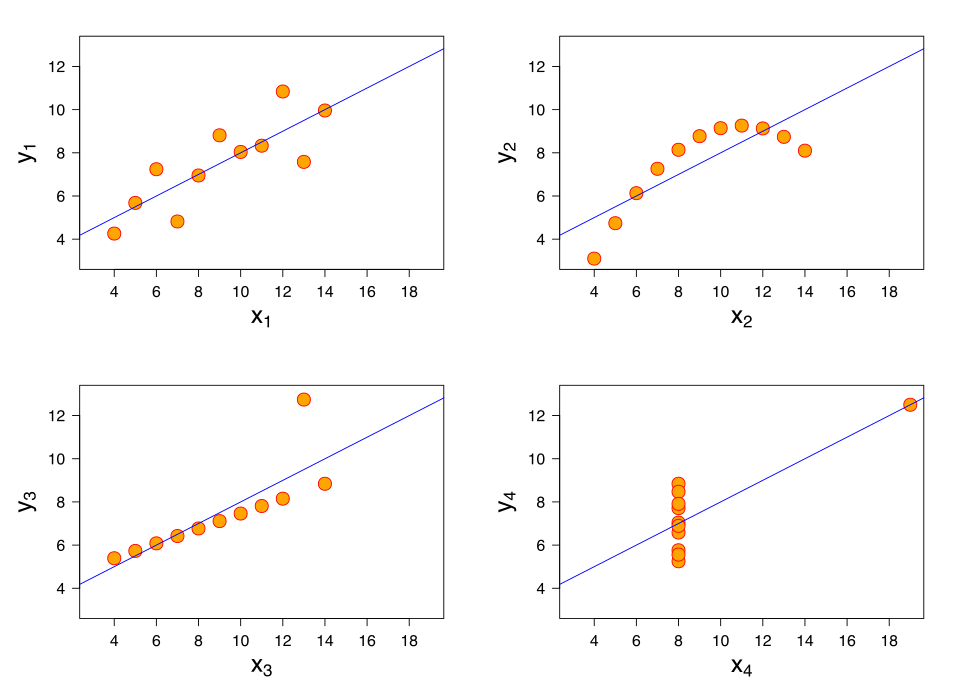

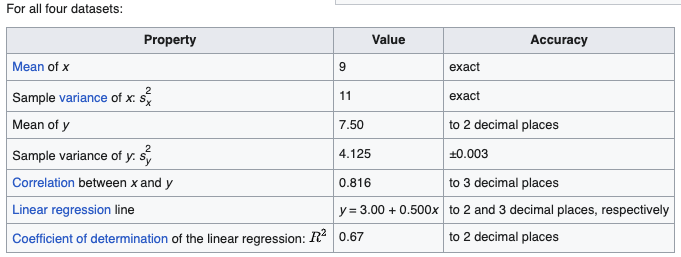

Anscombe's Quartet is a famous illustration of how datasets can have nearly identical descriptive statistics (like mean, variance, correlation, and even linear regression coefficients) but vastly different distributions when plotted. It consists of four datasets that yield the same linear regression line but exhibit unique visual patterns in their scatter plots and residual plots. This quartet shows us that:

- **Summary Statistics Can Be Misleading**: Relying solely on numerical summaries can lead to incorrect conclusions about the data's structure and the appropriateness of a linear model.

- **Visualization is Crucial**: Plotting data is essential to understand its true underlying relationships and to identify patterns that summary statistics might hide.

- **Assumptions Matter**: The different plots in Anscombe's Quartet highlight how different data patterns (e.g., non-linearity, outliers, influential points) can lead to the same regression line, yet invalidate the assumptions of linear regression for some datasets.


We can be mistaken if we don't visually inspect our data and residuals, as a model that appears statistically sound based on metrics alone might be a poor fit for the actual data distribution.

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

quartet_files = [
    'anscombes_quartet1.csv',
    'anscombes_quartet2.csv',
    'anscombes_quartet3.csv',
    'anscombes_quartet4.csv'
]

for i, file_name in enumerate(quartet_files):
    quartet = pd.read_csv(file_name)
    # Ensure consistent column names for quartet 2 as it's missing headers
    if file_name == 'anscombes_quartet2.csv':
        quartet.columns = ['x', 'y']

    # The linear regression equation for all quartets is y = 3 + 0.5x
    quartet['pred_y'] = 3 + 0.5 * quartet['x']

    # Calculate metrics
    mae = mean_absolute_error(quartet['y'], quartet['pred_y'])
    mse = mean_squared_error(quartet['y'], quartet['pred_y'])
    rmse = np.sqrt(mse)
    r2 = r2_score(quartet['y'], quartet['pred_y'])

    print(f"\n--- Anscombe's Quartet Dataset {i + 1} ({file_name}) ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")



--- Anscombe's Quartet Dataset 1 (anscombes_quartet1.csv) ---
MAE:  0.8373
MSE:  1.2512
RMSE: 1.1186
R2:   0.6665

--- Anscombe's Quartet Dataset 2 (anscombes_quartet2.csv) ---
MAE:  0.9682
MSE:  1.2524
RMSE: 1.1191
R2:   0.6662

--- Anscombe's Quartet Dataset 3 (anscombes_quartet3.csv) ---
MAE:  0.7164
MSE:  1.2506
RMSE: 1.1183
R2:   0.6663

--- Anscombe's Quartet Dataset 4 (anscombes_quartet4.csv) ---
MAE:  0.9027
MSE:  1.2493
RMSE: 1.1177
R2:   0.6667


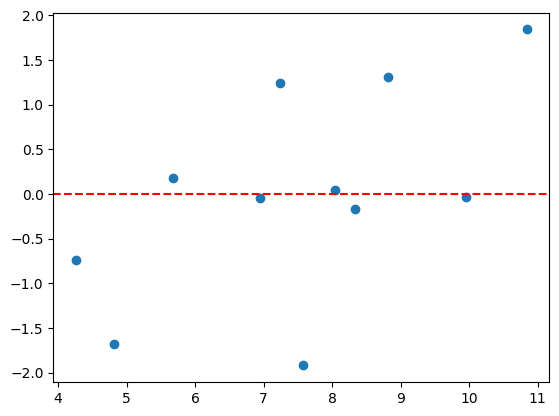

In [16]:
quartet = pd.read_csv('anscombes_quartet1.csv')
# y = 3.00 + 0.500x
quartet['pred_y'] = 3 + 0.5 * quartet['x']
quartet['residual'] = quartet['y'] - quartet['pred_y']
plt.scatter(data=quartet,x='y',y='residual')
plt.axhline(y=0, color='r', linestyle='--')

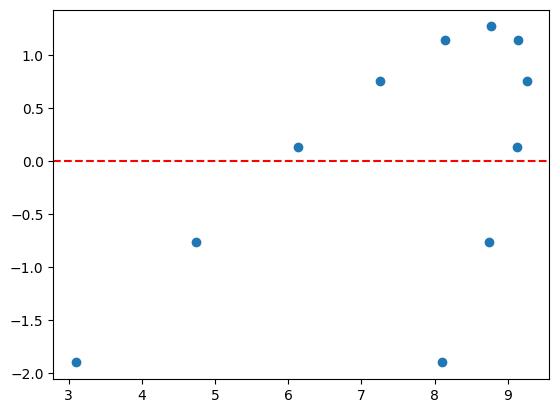

In [17]:
quartet = pd.read_csv('anscombes_quartet2.csv')
quartet.columns = ['x','y']
quartet['pred_y'] = 3 + 0.5 * quartet['x']
quartet['residual'] = quartet['y'] - quartet['pred_y']
plt.scatter(data=quartet,x='y',y='residual')
plt.axhline(y=0, color='r', linestyle='--')


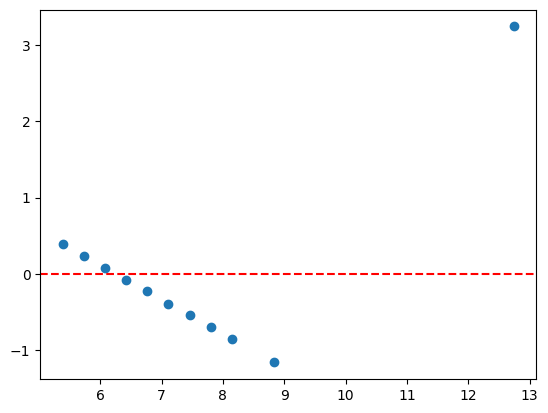

In [18]:
quartet = pd.read_csv('anscombes_quartet3.csv')
# y = 3.00 + 0.500x
quartet['pred_y'] = 3 + 0.5 * quartet['x']
quartet['residual'] = quartet['y'] - quartet['pred_y']
plt.scatter(data=quartet,x='y',y='residual')
plt.axhline(y=0, color='r', linestyle='--')

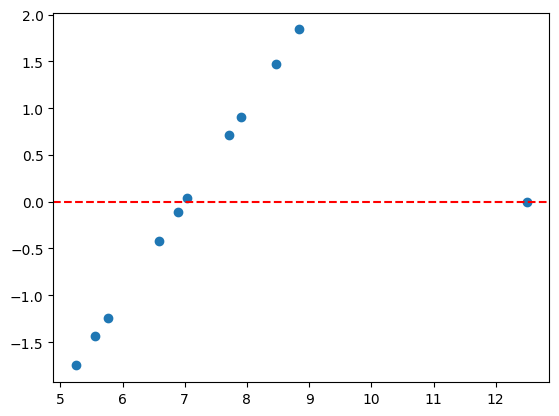

In [19]:
quartet = pd.read_csv('anscombes_quartet4.csv')
# y = 3.00 + 0.500x
quartet['pred_y'] = 3 + 0.5 * quartet['x']
quartet['residual'] = quartet['y'] - quartet['pred_y']
plt.scatter(data=quartet,x='y',y='residual')
plt.axhline(y=0, color='r', linestyle='--')

<br><br>

## **Plotting Residuals**

It's also important to plot out residuals and check for normal distribution, this helps us understand if Linear Regression was a valid model choice.

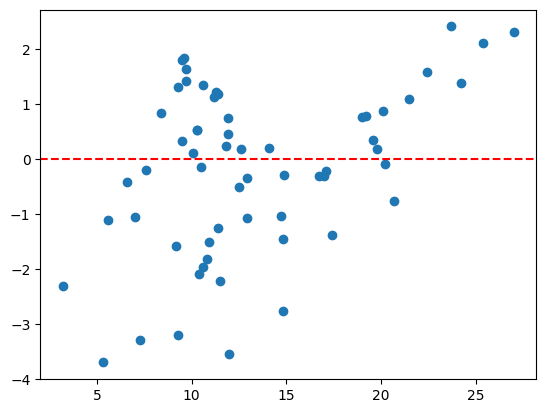

In [20]:
test_predictions = model.predict(X_test)
test_res = y_test - test_predictions

plt.scatter(x=y_test,y=test_res)
plt.axhline(y=0, color='r', linestyle='--')

<br><br>

## **Retraining Model on Full Data**

If we're satisfied with the performance on the test data, before deploying our model to the real world, we can retrain on all our data. (If we were not satisfied, we could update parameters or choose another model, something we'll discuss later on).

In [21]:
final_model = LinearRegression()

In [22]:
final_model.fit(X,y)

LinearRegression()

## **Deployment, Predictions, and Model Attributes**

In [23]:
y_hat = final_model.predict(X)

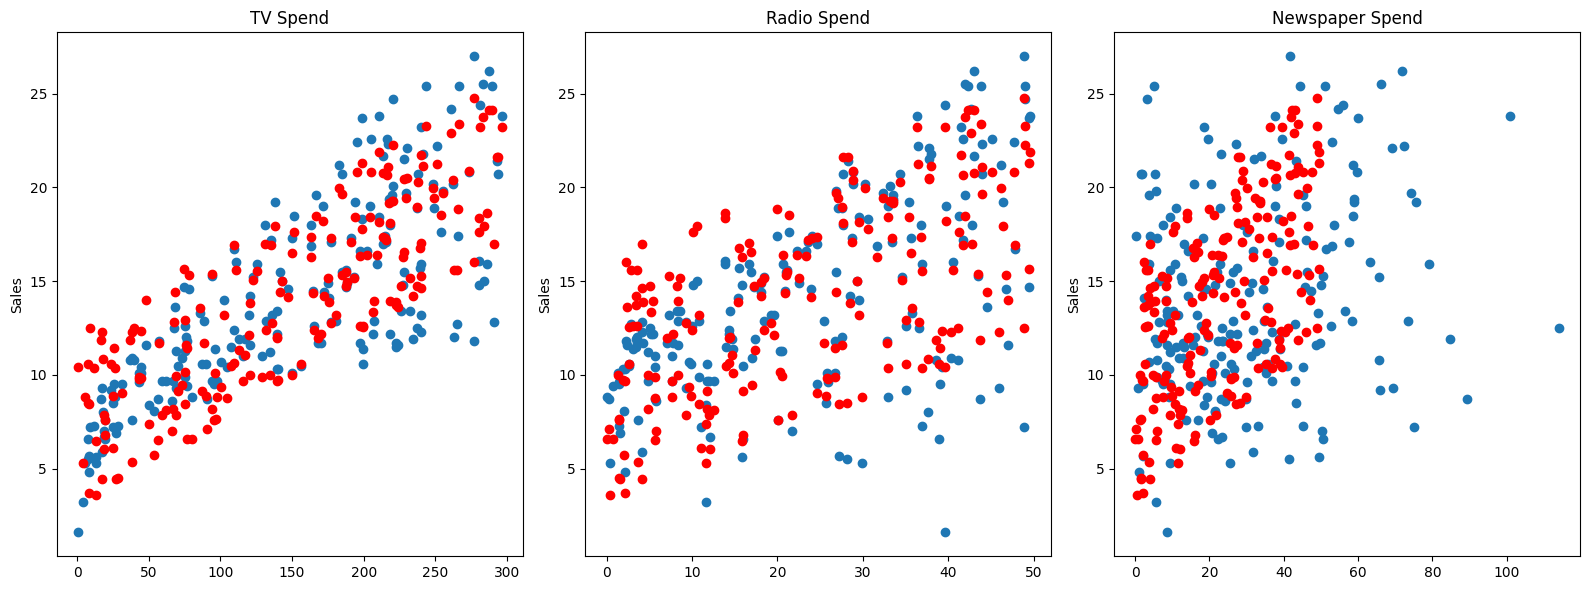

In [24]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'],y_hat,'o',color='red')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'],y_hat,'o',color='red')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['radio'],y_hat,'o',color='red')
axes[2].set_title("Newspaper Spend");
axes[2].set_ylabel("Sales")
plt.tight_layout();

## **Interpreting the coefficients:**

- Positive → increases sales
- Negative → decreases sales
- Near zero → irrelevant feature

In [25]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [26]:
final_model.intercept_

np.float64(2.938889369459412)

In [27]:
coeff_df = pd.DataFrame(final_model.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
TV,0.045765
radio,0.188530
newspaper,-0.001037


* Holding all other features fixed, a 1 unit (A thousand dollars) increase in TV Spend is associated with an increase in sales of  0.045 "sales units", in this case 1000s of units .
* This basically means that for every $1000 dollars spend on TV Ads, we could expect 45 more units sold.

* Holding all other features fixed, a 1 unit (A thousand dollars) increase in Radio Spend is associated with an increase in sales of  0.188 "sales units", in this case 1000s of units .
* This basically means that for every $1000 dollars spend on Radio Ads, we could expect 188 more units sold.


* Holding all other features fixed, a 1 unit (A thousand dollars) increase in Newspaper Spend is associated with a **decrease** in sales of  0.001 "sales units", in this case 1000s of units .
* This basically means that for every $1000 dollars spend on Newspaper Ads, we could actually expect to sell 1 less unit. Being so close to 0, this heavily implies that newspaper spend has no real effect on sales.


**Note:**

When you see a coefficient in a multiple regression model, it's not just showing the simple relationship between that single feature and the sales. Instead, it shows the relationship of that feature with sales while holding all other features (TV and radio spend in this case) constant.

So, the negative coefficient for Newspaper (-0.00103749) implies:

While TV and Radio spend are kept the same, an increase in Newspaper spend is associated with a very slight decrease in sales.



**Why might this happen?**
- Near Zero Effect (Most Likely Practical Interpretation): The coefficient value is extremely close to zero (-0.001), which practically means that newspaper advertising has almost no effect on sales. The negative sign, in this context, might just be statistical noise in a relationship that is essentially flat.

- Multicollinearity: It's possible that Newspaper advertising spend is correlated with other advertising channels. For example, perhaps companies that spend a lot on TV and Radio (which are effective) also tend to spend money on Newspaper. The model might be attributing the positive effect primarily to TV and Radio, and then trying to isolate the unique contribution of Newspaper. If Newspaper spend doesn't add much unique value, or even if it's used by companies whose overall strategy might be less efficient (when TV/radio are accounted for), its coefficient could turn negative. This doesn't mean Newspaper ads cause sales to go down, but that among firms with similar TV and Radio spend, those who spend more on Newspaper tend to have slightly lower sales.

- Substitution/Diminishing Returns: In some markets, money spent on Newspaper might be better allocated to other, more effective channels. So, if you increase Newspaper spend without increasing TV/Radio, or if you divert funds from more effective channels to Newspaper, it could indeed lead to a marginal decrease in overall sales effectiveness.


<br><br>

## **Model Deployment (Save & Load)**

- Deployment = persistence
- Share model without retraining

In [28]:
from joblib import dump, load

dump(model, "final_sales_model.joblib")
loaded_model = load("final_sales_model.joblib")

In [35]:
import pandas as pd

# Create some new, unseen advertising spend data
new_ad_spend = pd.DataFrame({
    'TV': [150, 20, 250],
    'radio': [30, 5, 45],
    'newspaper': [10, 8, 15]
})

print("New Advertising Spend:\n")
display(new_ad_spend)

# Use the loaded model to make predictions
new_predictions = loaded_model.predict(new_ad_spend)

# Add the predicted sales as a new column to the DataFrame
new_ad_spend['Predicted Sales'] = new_predictions

print("\n\n\nNew Advertising Spend with Predicted Sales:\n")
display(new_ad_spend)

New Advertising Spend:



,TV,radio,newspaper
0,150,30,10
1,20,5,8
2,250,45,15





New Advertising Spend with Predicted Sales:



,TV,radio,newspaper,Predicted Sales
0,150,30,10,15.479669
1,20,5,8,4.980693
2,250,45,15,22.761140
